# Esercizi con Librosa: Analisi di Segnali Audio

Questo notebook ti aiuterà a familiarizzare con **librosa** seguendo le indicazioni del progetto:

**Obiettivi**:
1. Studiare la teoria di Fourier e Short-Time Fourier Transform (dalla tesi)
2. Caricare un segnale vocale
3. Calcolare lo spettro di Fourier
4. Calcolare lo Spettrogramma

---

## Setup: Installazione e Import

Prima di iniziare, installa librosa:
```bash
pip install librosa matplotlib numpy scipy soundfile
```

In [3]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

# Configurazione per grafici leggibili
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10
print("✓ Librosa version:", librosa.__version__)
print("✓ Setup completato!")

✓ Librosa version: 0.11.0
✓ Setup completato!


---
## Parte 1: Caricamento di un Segnale Vocale

### ESERCIZIO 1: Carica un file audio

**Obiettivo**: Caricare un segnale audio e visualizzare le sue proprietà base.

**Suggerimenti**:
- Puoi usare un file di esempio di librosa con `librosa.example('trumpet')` o `librosa.example('libri1')`
- Oppure carica un tuo file con `librosa.load('percorso/file.wav')`
- La funzione `librosa.load()` restituisce due valori: il segnale `y` e la frequenza di campionamento `sr`
- Stampa la durata in secondi: `len(y)/sr`
- Stampa il numero di campioni: `len(y)`

In [37]:
# TODO: Carica un file audio
# Opzione 1: File di esempio
audio_path = librosa.example('trumpet')

# Opzione 2: Tuo file
# audio_path = 'percorso/del/tuo/file.wav'

# TODO: Carica il segnale
y, sr = librosa.load(audio_path)

# TODO: Stampa le informazioni
print(f"Frequenza di campionamento: {sr} Hz")
print(f"Durata: {len(y)/sr} secondi")
print(f"Numero di campioni: {len(y)}")

Frequenza di campionamento: 22050 Hz
Durata: 5.333378684807256 secondi
Numero di campioni: 117601


### 🏋️ ESERCIZIO 2: Ascolta e visualizza il segnale

**Obiettivo**: Ascolta il file audio e visualizza la sua forma d'onda.

**Suggerimenti**:
- Usa `ipd.Audio(y, rate=sr)` per ascoltare l'audio
- Usa `librosa.display.waveshow(y, sr=sr)` per visualizzare la forma d'onda
- Aggiungi titolo ed etichette con `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

In [38]:
# TODO: Riproduci l'audio
ipd.Audio(y, rate=sr)

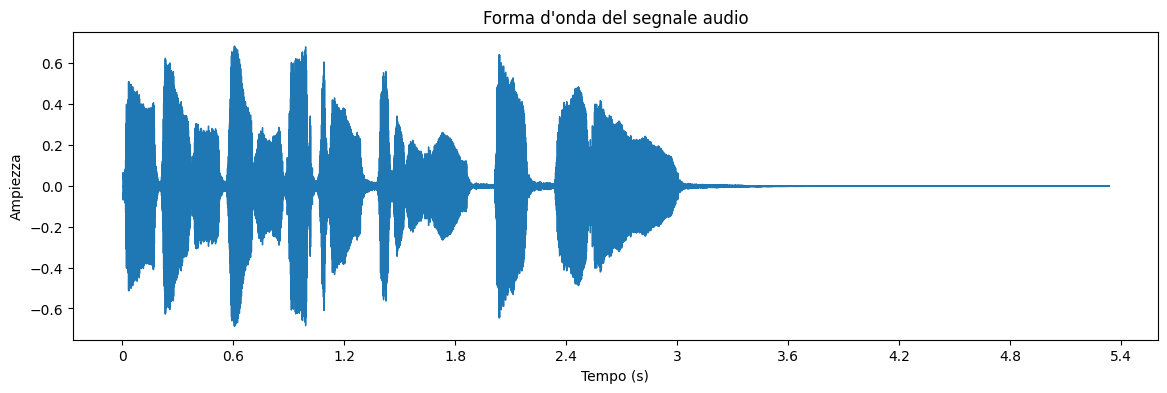

In [39]:
# TODO: Visualizza la forma d'onda
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Forma d\'onda del segnale audio')
plt.xlabel('Tempo (s)')
plt.ylabel('Ampiezza')
plt.show()

---
## Parte 2: Calcolo dello Spettro di Fourier

### Teoria dalla tesi:
La **trasformata di Fourier** permette di analizzare il contenuto frequenziale di un segnale, scomponendolo nelle sue componenti sinusoidali. La **Fast Fourier Transform (FFT)** è un algoritmo efficiente per calcolare la trasformata di Fourier discreta.

### ESERCIZIO 3: Calcola lo spettro di Fourier con FFT

**Obiettivo**: Applicare la FFT al segnale e visualizzare lo spettro di magnitudine.

**Suggerimenti**:
- Usa `np.fft.fft(y)` per calcolare la FFT
- Calcola la magnitudine con `np.abs(fft_result)`
- Calcola le frequenze corrispondenti con `np.fft.fftfreq(len(y), 1/sr)`
- La FFT è simmetrica: visualizza solo le frequenze positive (prima metà del vettore)
- Limita la visualizzazione a 5000 Hz con `plt.xlim(0, 5000)`

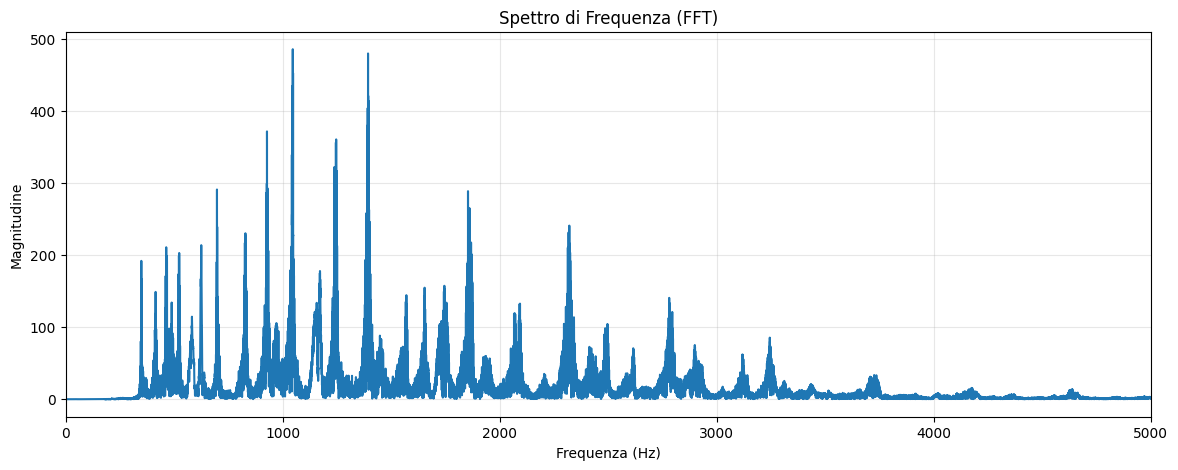

In [ ]:
# TODO: Calcola la FFT
fft_values = np.fft.fft(y)

# TODO: Calcola la magnitudine
magnitude = np.abs(fft_values)

# TODO: Calcola le frequenze
frequencies = np.fft.fftfreq(len(fft_values), 1/sr)

# TODO: Prendi solo le frequenze positive
positive_frequencies = frequencies[:len(frequencies)//2]

# TODO: Visualizza lo spettro
plt.figure(figsize=(14, 5))
plt.plot(positive_frequencies, positive_magnitude)
plt.title('Spettro di Frequenza (FFT)')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Magnitudine')
plt.xlim(0, 5000)
plt.grid(True, alpha=0.3)
plt.show()

### ESERCIZIO 4: Test con segnale sintetico

**Obiettivo**: Verifica il funzionamento della FFT creando un segnale composto da frequenze note.

**Suggerimenti**:
- Crea un segnale con 3 sinusoidi di frequenze 440 Hz, 880 Hz, 1320 Hz
- Formula: `np.sin(2 * np.pi * freq * t)`
- Somma le tre sinusoidi
- Applica la FFT
- Verifica che i picchi compaiano alle frequenze corrette

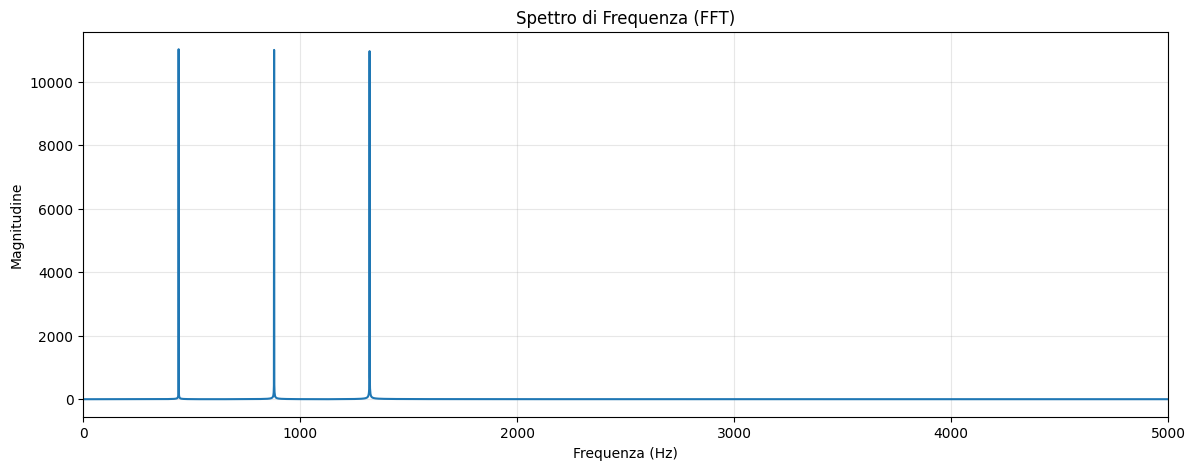

In [41]:
# TODO: Parametri
duration = 1.0  # secondi
sr_test = 22050  # frequenza di campionamento
t = np.linspace(0, duration, int(sr_test * duration))

# TODO: Crea tre sinusoidi
freq1, freq2, freq3 = 440, 880, 1320
sin1 = np.sin(2 * np.pi * freq1 * t)
sin2 = np.sin(2 * np.pi * freq2 * t)
sin3 = np.sin(2 * np.pi * freq3 * t)

# TODO: Somma le sinusoidi
signal_test = sin1 + sin2 + sin3

# TODO: Applica FFT e visualizza (come nell'esercizio precedente)

fft_values = np.fft.fft(signal_test)
magnitude = np.abs(fft_values)
frequencies = np.fft.fftfreq(len(fft_values), 1/sr_test)

positive_frequencies = frequencies[:len(frequencies)//2]
positive_magnitude = magnitude[:len(magnitude)//2]

# TODO: Visualizza lo spettro
plt.figure(figsize=(14, 5))
plt.plot(positive_frequencies, positive_magnitude)
plt.title('Spettro di Frequenza (FFT)')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Magnitudine')
plt.xlim(0, 5000)
plt.grid(True, alpha=0.3)
plt.show()
# BONUS: Ascolta il segnale creato
ipd.Audio(signal_test, rate=sr_test)

---
## Parte 3: Calcolo dello Spettrogramma (STFT)

### Teoria dalla tesi:
La trasformata di Fourier classica mostra **quali** frequenze sono presenti, ma non **quando** compaiono. Per segnali **non stazionari** (che cambiano nel tempo, come la voce), serve la **Short-Time Fourier Transform (STFT)**: si applica la FFT su finestre temporali successive.

Lo **spettrogramma** è la rappresentazione visuale della STFT nel piano tempo-frequenza.

### ESERCIZIO 5: Calcola la STFT

**Obiettivo**: Calcola la Short-Time Fourier Transform del segnale.

**Suggerimenti**:
- Usa `librosa.stft(y, n_fft=2048, hop_length=512)`
  - `n_fft`: lunghezza della finestra FFT (es: 2048 campioni)
  - `hop_length`: spostamento tra finestre successive (es: 512 campioni)
- Il risultato è una matrice complessa di dimensioni `(freq_bins, time_frames)`
- Converti in magnitudine decibel: `librosa.amplitude_to_db(np.abs(D), ref=np.max)`

In [42]:
# TODO: Definisci i parametri
n_fft = 2048
hop_length = 512

# TODO: Calcola la STFT
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)

# TODO: Converti in decibel
magnitude_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# TODO: Stampa la forma della matrice
print(f"Forma STFT: {D.shape}")
print(f"Bin di frequenza: {D.shape[0]}")
print(f"Frame temporali: {D.shape[1]}")

Forma STFT: (1025, 230)
Bin di frequenza: 1025
Frame temporali: 230


### ESERCIZIO 6: Visualizza lo spettrogramma

**Obiettivo**: Crea una rappresentazione visuale dello spettrogramma.

**Suggerimenti**:
- Usa `librosa.display.specshow(magnitude_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz')`
- Aggiungi una barra colori con `plt.colorbar(format='%+2.0f dB')`
- Limita l'asse y a 8000 Hz: `plt.ylim(0, 8000)`
- Scegli una colormap (es: 'viridis', 'magma', 'coolwarm')

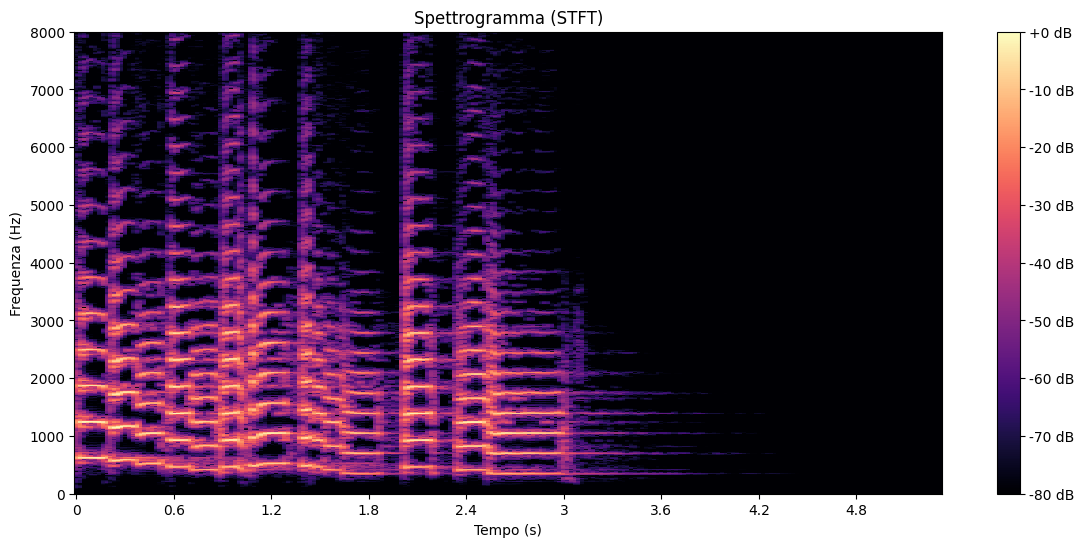

In [43]:
# TODO: Visualizza lo spettrogramma
plt.figure(figsize=(14, 6))
librosa.display.specshow(magnitude_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma (STFT)')
plt.xlabel('Tempo (s)')
plt.ylabel('Frequenza (Hz)')
plt.ylim(0, 8000)
plt.show()

### ESERCIZIO 7: Principio di indeterminazione

**Obiettivo**: Esplora il trade-off tra risoluzione temporale e risoluzione frequenziale.

**Teoria dalla tesi**: Il **principio di indeterminazione** afferma che non si possono avere simultaneamente alta risoluzione temporale e alta risoluzione frequenziale.

- **Finestra piccola** (`n_fft=512`): buona risoluzione temporale, scarsa risoluzione frequenziale
- **Finestra grande** (`n_fft=4096`): scarsa risoluzione temporale, buona risoluzione frequenziale

**Suggerimenti**:
- Calcola due STFT con `n_fft` diversi
- Visualizza i due spettrogrammi affiancati con `plt.subplot(2, 1, 1)` e `plt.subplot(2, 1, 2)`
- Confronta i risultati

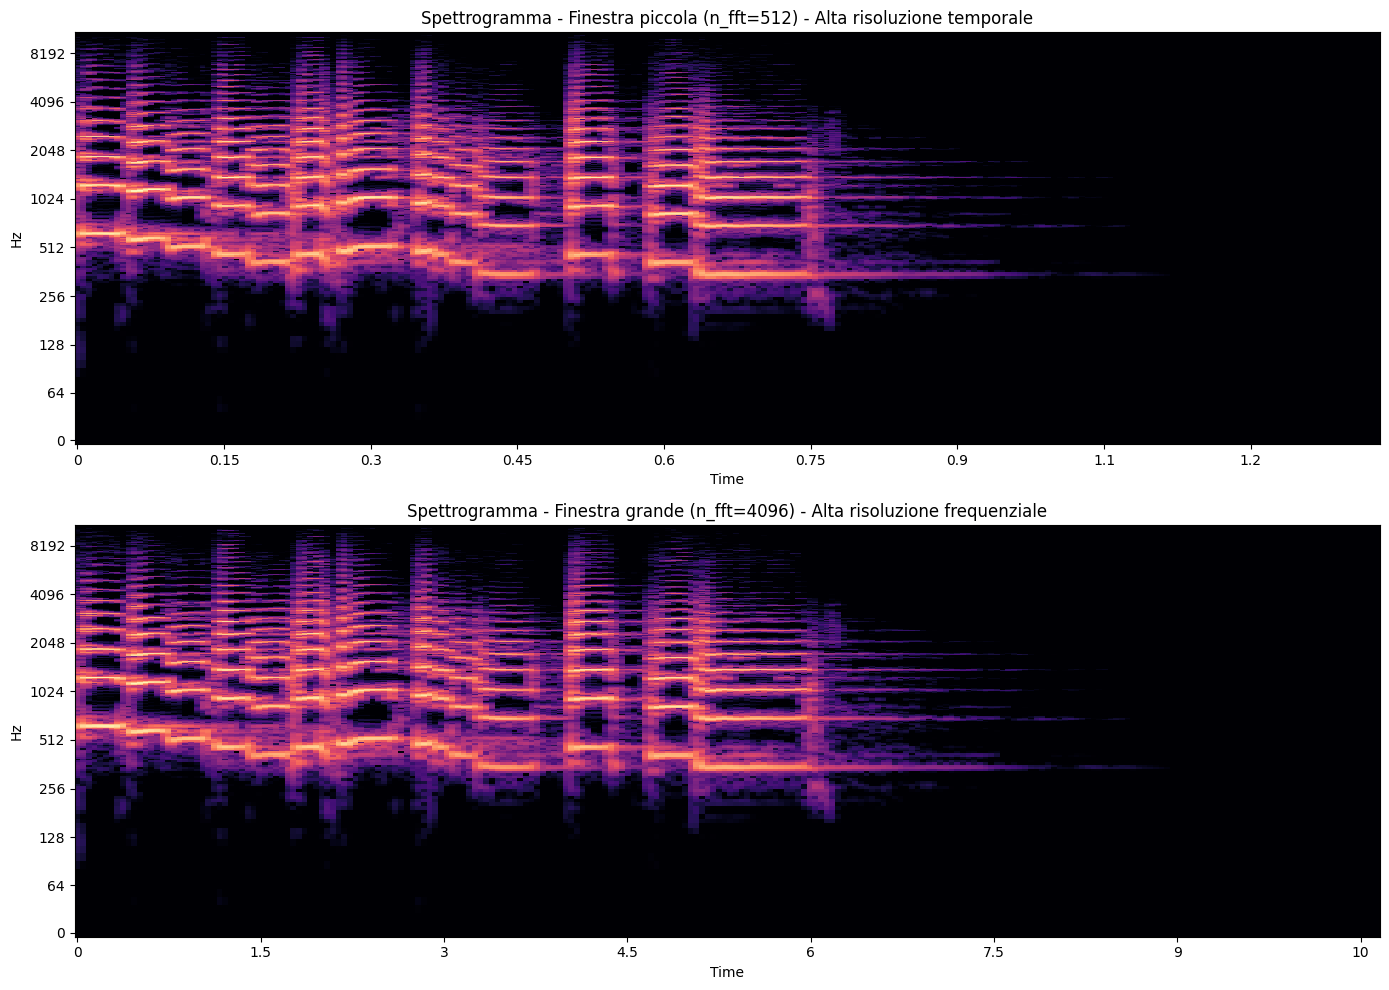

In [44]:
# TODO: STFT con finestra piccola
n_fft_small = 512
hop_small = 128
D_small = librosa.stft(y, n_fft=n_fft_small, hop_length=hop_small)
mag_small_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# TODO: STFT con finestra grande
n_fft_large = 4096
hop_large = 1024
D_large = librosa.stft(y, n_fft=n_fft_small, hop_length=hop_large)
mag_large_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# TODO: Visualizza entrambi
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
librosa.display.specshow(mag_small_db, sr=sr, hop_length=hop_small, x_axis='time', y_axis='log')
plt.title('Spettrogramma - Finestra piccola (n_fft=512) - Alta risoluzione temporale')

plt.subplot(2, 1, 2)
librosa.display.specshow(mag_large_db, sr=sr, hop_length=hop_large, x_axis='time', y_axis='log')
plt.title('Spettrogramma - Finestra grande (n_fft=4096) - Alta risoluzione frequenziale')

plt.tight_layout()
plt.show()

**Domanda di riflessione**: Quale differenza noti tra i due spettrogrammi? Quando useresti una finestra piccola e quando una grande?

---
## Parte 5: Confronto affiancato

### ESERCIZIO 9: Crea un confronto completo

**Obiettivo**: Visualizza insieme forma d'onda, spettro di Fourier, e spettrogramma.

**Suggerimenti**:
- Usa `plt.subplot(3, 1, n)` per creare 3 grafici in verticale
- Grafico 1: Forma d'onda
- Grafico 2: Spettro di Fourier
- Grafico 3: Spettrogramma

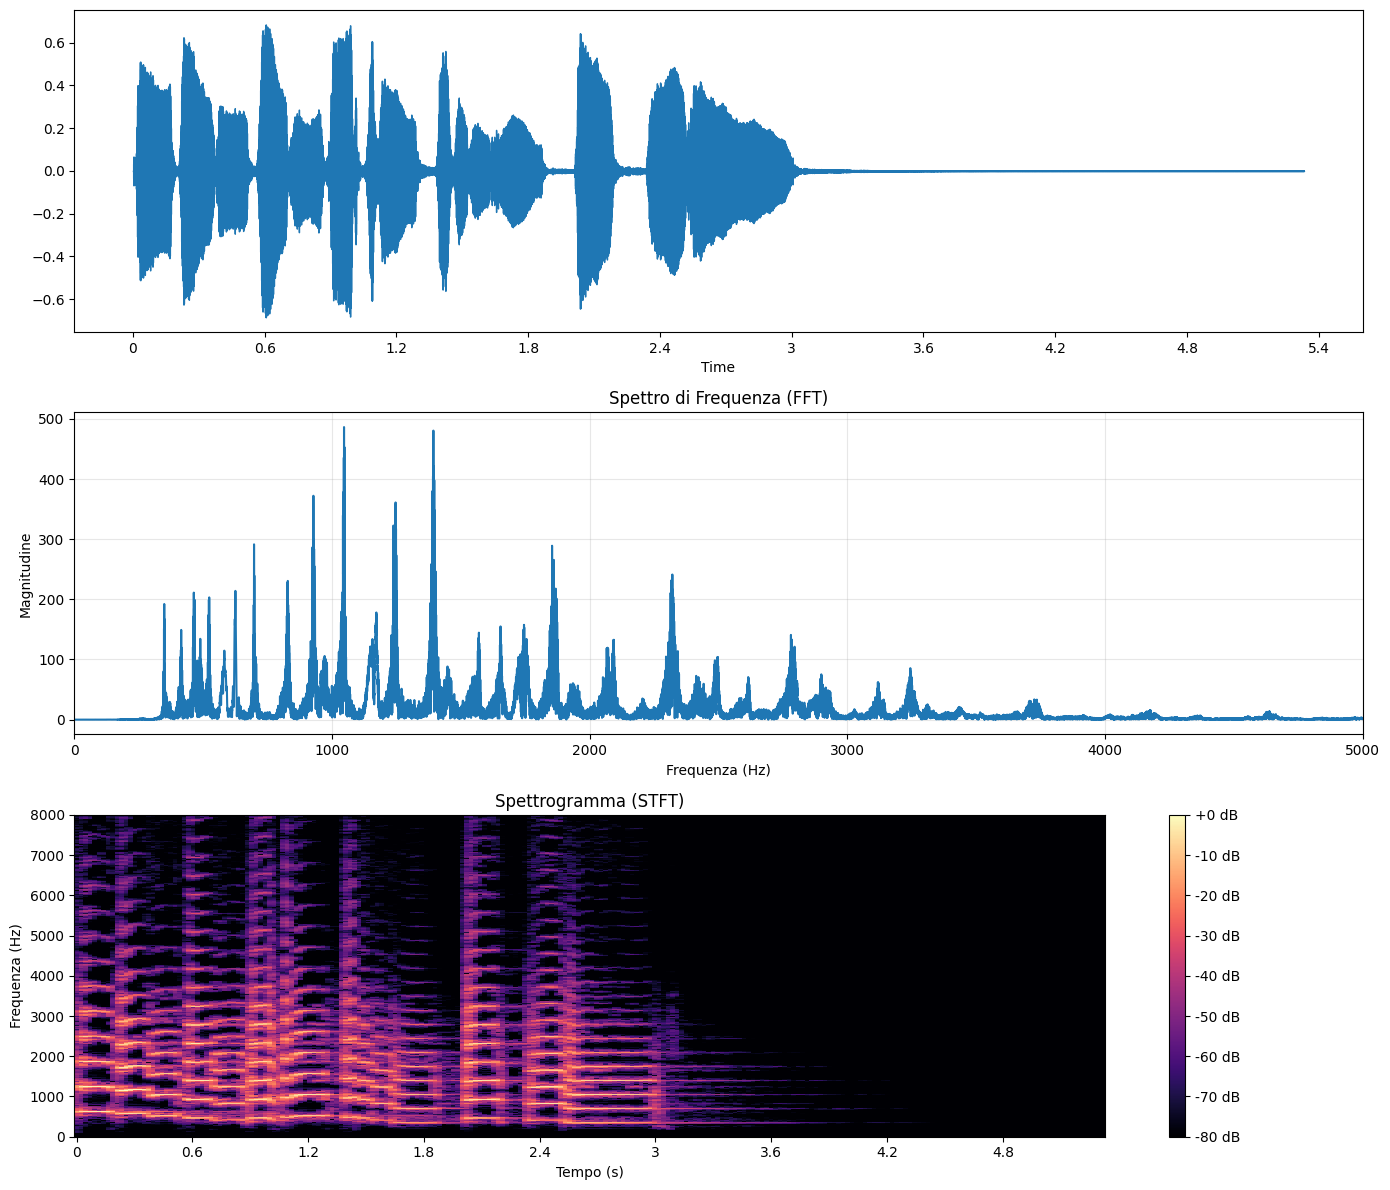

In [45]:
# TODO: Crea una figura con 3 subplot
plt.figure(figsize=(14, 12))


# TODO: Subplot 1 - Waveform
plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr)

# TODO: Subplot 2 - Spettro FFT
plt.subplot(3, 1, 2)
fft_values = np.fft.fft(y)
magnitude = np.abs(fft_values)
frequencies = np.fft.fftfreq(len(fft_values), 1/sr)

positive_frequencies = frequencies[:len(frequencies)//2]
positive_magnitude = magnitude[:len(magnitude)//2]

plt.plot(positive_frequencies, positive_magnitude)
plt.title('Spettro di Frequenza (FFT)')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Magnitudine')
plt.xlim(0, 5000)
plt.grid(True, alpha=0.3)

# TODO: Subplot 3 - Spettrogramma
plt.subplot(3, 1, 3)
n_fft = 2048
hop_length = 512
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
magnitude_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(magnitude_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spettrogramma (STFT)')
plt.xlabel('Tempo (s)')
plt.ylabel('Frequenza (Hz)')
plt.ylim(0, 8000)

plt.tight_layout()
plt.show()